<a href="https://www.kaggle.com/code/aamir28/student-side-hustle-money-habits-eda?scriptVersionId=338971700" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<div style="background: linear-gradient(135deg, #1a2744 0%, #24365c 55%, #2e8b8b 140%); padding:48px 40px; border-radius:14px; box-shadow:0 4px 20px rgba(0,0,0,0.25); font-family:'Segoe UI',Arial,sans-serif;">
<p style="color:#c76b3f; font-weight:700; letter-spacing:2px; font-size:13px; margin:0 0 10px 0; text-transform:uppercase;">Exploratory Data Analysis &nbsp;·&nbsp; 2026 Edition</p>
<h1 style="color:white; font-size:36px; font-weight:700; margin:0 0 14px 0; line-height:1.2;">Student Side Hustle &amp; Money Habits</h1>
<p style="color:#c9d3e3; font-size:16px; line-height:1.6; margin:0 0 22px 0; max-width:680px;">
How students earn, spend, save, and stress about money while chasing a GPA — a full exploratory
analysis of 2,500 students, covering income sources, side hustles, debt, savings behavior, AI tool
adoption, and financial wellbeing.
</p>
<table style="border-collapse:collapse;"><tr>
<td style="background:rgba(255,255,255,0.12); border-radius:8px; padding:10px 18px; margin-right:10px;"><span style="color:white; font-size:13px;">&#128202; 2,500 students</span></td>
</tr></table>
</div>

<div style="margin-top:6px;">
<table style="border-collapse:collapse; width:100%;"><tr>
<td style="background:#f4f6f9; border-radius:8px; padding:14px 18px; text-align:center; width:25%;"><b style="color:#1a2744; font-size:20px;">40</b><br><span style="color:#6b7684; font-size:12px;">COLUMNS</span></td>
<td style="width:2%;"></td>
<td style="background:#f4f6f9; border-radius:8px; padding:14px 18px; text-align:center; width:25%;"><b style="color:#1a2744; font-size:20px;">11</b><br><span style="color:#6b7684; font-size:12px;">VISUALIZATIONS</span></td>
<td style="width:2%;"></td>
<td style="background:#f4f6f9; border-radius:8px; padding:14px 18px; text-align:center; width:25%;"><b style="color:#1a2744; font-size:20px;">10</b><br><span style="color:#6b7684; font-size:12px;">SECTIONS</span></td>
<td style="width:2%;"></td>
<td style="background:#f4f6f9; border-radius:8px; padding:14px 18px; text-align:center; width:25%;"><b style="color:#1a2744; font-size:20px;">0</b><br><span style="color:#6b7684; font-size:12px;">MISSING FROM PLOTS</span></td>
</tr></table>
</div>

<div style="background:white; border:1px solid #e3e7ee; border-radius:10px; padding:22px 26px; margin-top:18px; font-family:'Segoe UI',Arial,sans-serif;">
<p style="margin:0 0 10px 0; font-weight:700; color:#1a2744; font-size:15px;">Contents</p>
<table style="border-collapse:collapse; width:100%; font-size:14px; color:#3d4f6b;">
<tr><td style="padding:4px 0;">01</td><td style="padding:4px 0;">Data Overview &amp; Quality Check</td></tr>
<tr><td style="padding:4px 0;">02</td><td style="padding:4px 0;">Who Are These Students?</td></tr>
<tr><td style="padding:4px 0;">03</td><td style="padding:4px 0;">Work Hours vs. GPA</td></tr>
<tr><td style="padding:4px 0;">04</td><td style="padding:4px 0;">Where Student Money Comes From</td></tr>
<tr><td style="padding:4px 0;">05</td><td style="padding:4px 0;">Debt, Stress &amp; the BNPL Trap</td></tr>
<tr><td style="padding:4px 0;">06</td><td style="padding:4px 0;">Financial Stress vs. GPA</td></tr>
<tr><td style="padding:4px 0;">07</td><td style="padding:4px 0;">The AI-for-Schoolwork Trend</td></tr>
<tr><td style="padding:4px 0;">08</td><td style="padding:4px 0;">Impulse Spending &amp; Lifestyle Creep</td></tr>
<tr><td style="padding:4px 0;">09</td><td style="padding:4px 0;">Income vs. Savings</td></tr>
<tr><td style="padding:4px 0;">10</td><td style="padding:4px 0;">Correlation Heatmap &amp; Key Takeaways</td></tr>
</table>
</div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import HTML, display

# --- Visual theme, tuned to match the notebook's HTML design system ---
NAVY, SLATE, ACCENT, ACCENT2 = "#1a2744", "#3d4f6b", "#2e8b8b", "#c76b3f"
PALETTE = [ACCENT, ACCENT2, "#5b7fb5", "#8a6bb0", "#5ba86e", "#c9a227", "#b5651d", "#7a7a7a"]

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 11,
    "font.family": "sans-serif",
    "axes.edgecolor": "#d8dce3",
    "axes.labelcolor": SLATE,
    "text.color": NAVY,
    "xtick.color": SLATE,
    "ytick.color": SLATE,
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.titlecolor": NAVY,
    "grid.color": "#eceff3",
})
sns.set_palette(PALETTE)

df = pd.read_csv("/kaggle/input/datasets/aamir28/student-side-hustle-and-money-habits-2026/student_money_habits_2026.csv")
print(f"Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")

Dataset loaded: 2,500 rows x 40 columns


<div style="background:#f4f6f9; border-left:5px solid #2e7d5b; padding:16px 20px; border-radius:6px; margin:6px 0 24px 0; font-family:'Segoe UI',Arial,sans-serif;">
<p style="margin:0 0 6px 0; font-weight:700; color:#2e7d5b; font-size:14px;">&#9989;&nbsp; Setup complete</p>
<p style="margin:0; color:#2a2a2a; font-size:14.5px; line-height:1.55;">The dataset loads cleanly with <b>2,500 rows and 40 columns</b>. A shared visual theme (navy/teal/copper palette) is applied globally so every chart in this notebook stays visually consistent.</p>
</div>

<div style="background: linear-gradient(135deg, #1a2744 0%, #3d4f6b 100%); padding: 28px 32px; border-radius: 10px; margin: 28px 0 18px 0; box-shadow: 0 2px 8px rgba(0,0,0,0.15);">
<table style="width:100%; border-collapse:collapse;"><tr>
<td style="width:56px; vertical-align:middle;">
<div style="background:#2e8b8b; color:white; width:44px; height:44px; border-radius:50%; display:flex; align-items:center; justify-content:center; font-size:20px; font-weight:700; font-family:Georgia,serif; text-align:center; line-height:44px;">01</div>
</td>
<td style="vertical-align:middle; padding-left:8px;">
<h2 style="color:white; margin:0; font-family:'Segoe UI',Arial,sans-serif; font-size:22px; font-weight:600; letter-spacing:0.3px;">Data Overview &amp; Quality Check</h2>
<p style="color:#b8c4d9; margin:4px 0 0 0; font-family:'Segoe UI',Arial,sans-serif; font-size:14px;">Structure, types, and completeness before diving into analysis</p>
</td>
</tr></table>
</div>

In [2]:
df.head()

,student_id,age,gender,region,major,year_level,living_situation,gpa,study_hours_per_week,has_job,...,credit_card_debt_balance,uses_buy_now_pay_later,bnpl_monthly_payments,monthly_savings,has_emergency_fund,uses_ai_tools_for_school,ai_tool_weekly_hours,pays_for_ai_subscription,financial_stress_score,financially_confident
0,STU100000,17,Male,Europe,Computer Science,Senior,Off-campus alone,2.91,14.7,False,...,0.0,False,0.00,0.00,False,True,8.4,True,6.7,False
1,STU100001,23,Male,Middle East,Psychology,Freshman,Off-campus with roommates,2.86,9.5,True,...,0.0,True,90.29,611.80,False,False,NaN,False,1.0,True
2,STU100002,22,Male,North America,Psychology,Sophomore,With parents,2.88,20.1,False,...,0.0,False,0.00,171.43,False,True,3.2,False,1.5,True
3,STU100003,20,Female,North America,Arts & Design,Sophomore,With parents,3.36,21.1,True,...,0.0,True,95.36,38.56,False,True,0.5,False,1.0,True
4,STU100004,20,Male,Europe,Psychology,Graduate,On-campus dorm,3.47,12.0,True,...,0.0,True,14.76,76.54,False,False,0.0,False,2.3,False


<div style="background:#f4f6f9; border-left:5px solid #2e8b8b; padding:16px 20px; border-radius:6px; margin:6px 0 24px 0; font-family:'Segoe UI',Arial,sans-serif;">
<p style="margin:0 0 6px 0; font-weight:700; color:#2e8b8b; font-size:14px;">&#128161;&nbsp; First look</p>
<p style="margin:0; color:#2a2a2a; font-size:14.5px; line-height:1.55;">Each row is one student. Columns span five themes: demographics, academics, employment/income, spending &amp; debt, and wellbeing &mdash; giving a 360&deg; financial snapshot per student.</p>
</div>

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 40 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   student_id                      2500 non-null   object 
 1   age                             2500 non-null   int64  
 2   gender                          2500 non-null   object 
 3   region                          2500 non-null   object 
 4   major                           2500 non-null   object 
 5   year_level                      2500 non-null   object 
 6   living_situation                2500 non-null   object 
 7   gpa                             2500 non-null   float64
 8   study_hours_per_week            2500 non-null   float64
 9   has_job                         2500 non-null   bool   
 10  job_type                        2500 non-null   object 
 11  work_hours_per_week             2500 non-null   float64
 12  monthly_job_income              25

<div style="background:#f4f6f9; border-left:5px solid #2e8b8b; padding:16px 20px; border-radius:6px; margin:6px 0 24px 0; font-family:'Segoe UI',Arial,sans-serif;">
<p style="margin:0 0 6px 0; font-weight:700; color:#2e8b8b; font-size:14px;">&#128161;&nbsp; Structure check</p>
<p style="margin:0; color:#2a2a2a; font-size:14.5px; line-height:1.55;">40 columns split cleanly across booleans (yes/no flags like <code>has_job</code>), numerics (dollar amounts, hours, GPA), and a handful of categorical fields (<code>major</code>, <code>job_type</code>, <code>impulse_purchase_frequency</code>). No column is entirely empty or mistyped.</p>
</div>

In [4]:
summary = df.describe(include="number").T
summary[["mean", "std", "min", "50%", "max"]].round(2)

,mean,std,min,50%,max
age,20.98,2.58,17.00,21.00,25.00
gpa,3.17,0.35,2.02,3.18,4.00
study_hours_per_week,14.69,6.45,1.00,14.60,39.70
work_hours_per_week,8.00,8.81,0.00,5.20,38.90
monthly_job_income,487.05,626.62,0.00,224.44,3000.00
num_side_hustles,0.59,0.81,0.00,0.00,3.00
family_support_monthly,282.38,315.41,0.00,182.98,1492.97
scholarship_monthly_equiv,102.60,180.77,0.00,0.00,872.68
total_monthly_income,872.48,719.15,0.00,735.56,4047.42
subscription_count,2.61,1.65,0.00,2.00,10.00


<div style="background:#f4f6f9; border-left:5px solid #2e8b8b; padding:16px 20px; border-radius:6px; margin:6px 0 24px 0; font-family:'Segoe UI',Arial,sans-serif;">
<p style="margin:0 0 6px 0; font-weight:700; color:#2e8b8b; font-size:14px;">&#128161;&nbsp; Distribution snapshot</p>
<p style="margin:0; color:#2a2a2a; font-size:14.5px; line-height:1.55;">GPA centers around <b>3.1&ndash;3.2</b> with a realistic spread, monthly income and spend both show wide right-skewed ranges (a mix of no-income and high-income students), and financial stress spans the full 1&ndash;10 scale &mdash; healthy variance for correlation analysis.</p>
</div>

In [5]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})

,missing_count,missing_pct
ai_tool_weekly_hours,62,2.48
monthly_savings,40,1.60
student_loan_balance,28,1.12
family_support_monthly,22,0.88


<div style="background:#f4f6f9; border-left:5px solid #2e7d5b; padding:16px 20px; border-radius:6px; margin:6px 0 24px 0; font-family:'Segoe UI',Arial,sans-serif;">
<p style="margin:0 0 6px 0; font-weight:700; color:#2e7d5b; font-size:14px;">&#9989;&nbsp; Data quality</p>
<p style="margin:0; color:#2a2a2a; font-size:14.5px; line-height:1.55;">Missingness is intentionally light (under 2.5% in any single column) and concentrated in optional/derived fields like <code>ai_tool_weekly_hours</code> and <code>monthly_savings</code> &mdash; realistic enough to practice imputation, but not so much that it undermines analysis.</p>
</div>

<div style="background: linear-gradient(135deg, #1a2744 0%, #3d4f6b 100%); padding: 28px 32px; border-radius: 10px; margin: 28px 0 18px 0; box-shadow: 0 2px 8px rgba(0,0,0,0.15);">
<table style="width:100%; border-collapse:collapse;"><tr>
<td style="width:56px; vertical-align:middle;">
<div style="background:#2e8b8b; color:white; width:44px; height:44px; border-radius:50%; display:flex; align-items:center; justify-content:center; font-size:20px; font-weight:700; font-family:Georgia,serif; text-align:center; line-height:44px;">02</div>
</td>
<td style="vertical-align:middle; padding-left:8px;">
<h2 style="color:white; margin:0; font-family:'Segoe UI',Arial,sans-serif; font-size:22px; font-weight:600; letter-spacing:0.3px;">Who Are These Students?</h2>
<p style="color:#b8c4d9; margin:4px 0 0 0; font-family:'Segoe UI',Arial,sans-serif; font-size:14px;">Year level, major, and living situation before we get into the money</p>
</td>
</tr></table>
</div>

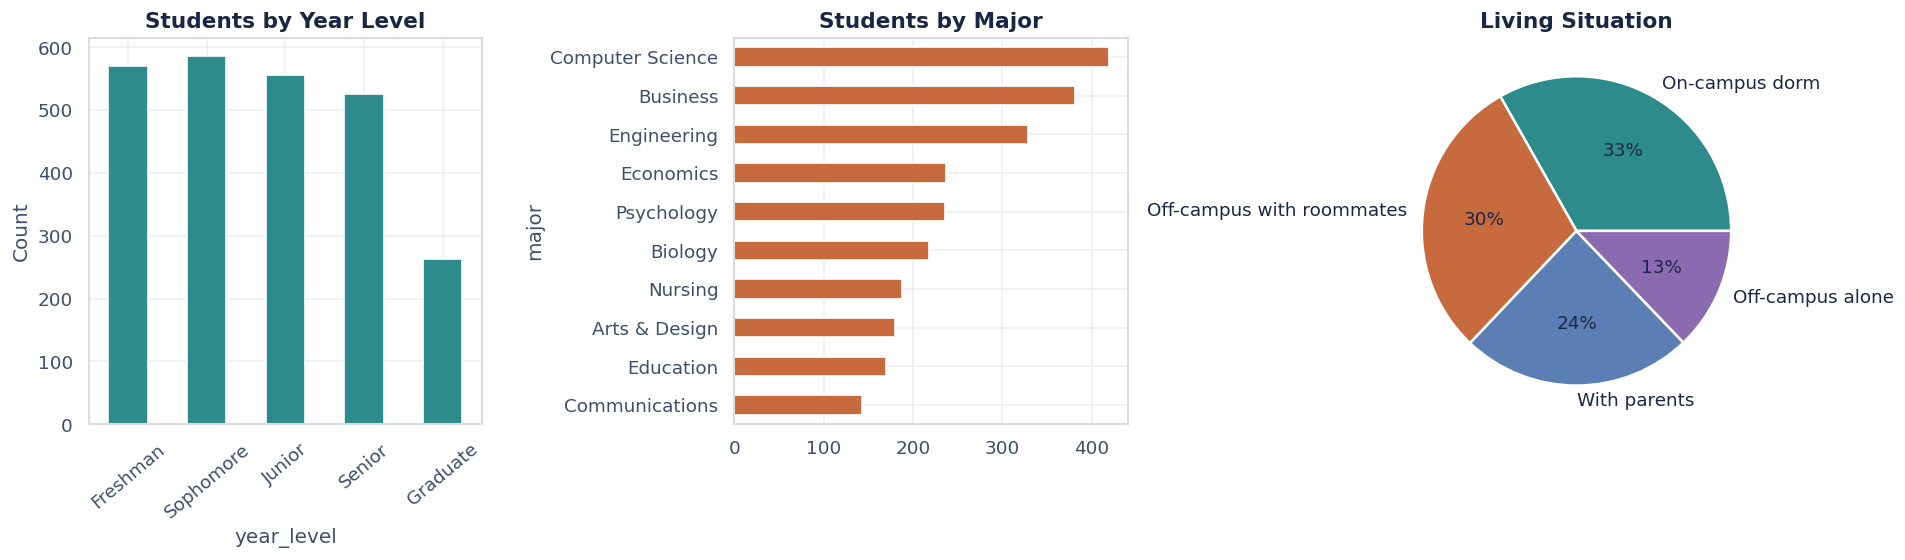

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

df["year_level"].value_counts().reindex(
    ["Freshman", "Sophomore", "Junior", "Senior", "Graduate"]
).plot(kind="bar", ax=axes[0], color=ACCENT, edgecolor="white")
axes[0].set_title("Students by Year Level")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=40)

df["major"].value_counts().plot(kind="barh", ax=axes[1], color=ACCENT2, edgecolor="white")
axes[1].set_title("Students by Major")
axes[1].invert_yaxis()

df["living_situation"].value_counts().plot(
    kind="pie", ax=axes[2], autopct="%1.0f%%", ylabel="",
    colors=PALETTE, wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)
axes[2].set_title("Living Situation")

plt.tight_layout()
plt.show()

<div style="background:#f4f6f9; border-left:5px solid #2e8b8b; padding:16px 20px; border-radius:6px; margin:6px 0 24px 0; font-family:'Segoe UI',Arial,sans-serif;">
<p style="margin:0 0 6px 0; font-weight:700; color:#2e8b8b; font-size:14px;">&#128161;&nbsp; Sample composition</p>
<p style="margin:0; color:#2a2a2a; font-size:14.5px; line-height:1.55;">The sample is fairly balanced across year levels (Freshman through Senior, plus a smaller Graduate slice), Computer Science and Business lead the major distribution, and roughly a third of students live in on-campus dorms &mdash; giving good coverage across student living situations for later comparisons.</p>
</div>

<div style="background: linear-gradient(135deg, #1a2744 0%, #3d4f6b 100%); padding: 28px 32px; border-radius: 10px; margin: 28px 0 18px 0; box-shadow: 0 2px 8px rgba(0,0,0,0.15);">
<table style="width:100%; border-collapse:collapse;"><tr>
<td style="width:56px; vertical-align:middle;">
<div style="background:#2e8b8b; color:white; width:44px; height:44px; border-radius:50%; display:flex; align-items:center; justify-content:center; font-size:20px; font-weight:700; font-family:Georgia,serif; text-align:center; line-height:44px;">03</div>
</td>
<td style="vertical-align:middle; padding-left:8px;">
<h2 style="color:white; margin:0; font-family:'Segoe UI',Arial,sans-serif; font-size:22px; font-weight:600; letter-spacing:0.3px;">Work Hours vs. GPA</h2>
<p style="color:#b8c4d9; margin:4px 0 0 0; font-family:'Segoe UI',Arial,sans-serif; font-size:14px;">The classic job-vs-grades trade-off &mdash; does it actually show up in the data?</p>
</td>
</tr></table>
</div>

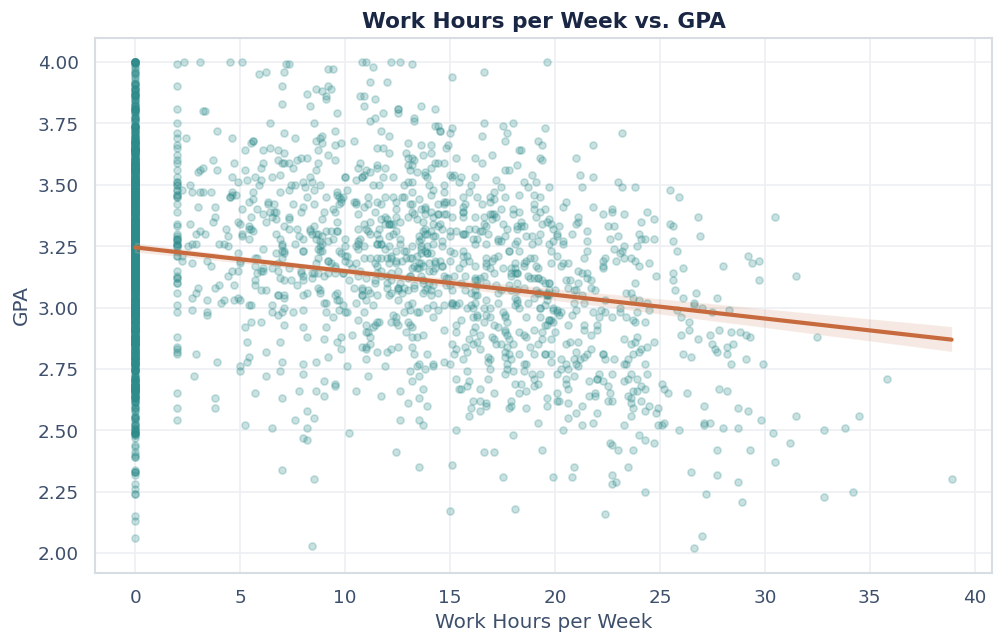

Pearson correlation: -0.240


In [7]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
sns.regplot(
    data=df, x="work_hours_per_week", y="gpa",
    scatter_kws={"alpha": 0.25, "s": 18, "color": ACCENT},
    line_kws={"color": ACCENT2, "linewidth": 2.5}
)
ax.set_title("Work Hours per Week vs. GPA")
ax.set_xlabel("Work Hours per Week")
ax.set_ylabel("GPA")
plt.tight_layout()
plt.show()

corr = df["work_hours_per_week"].corr(df["gpa"])
print(f"Pearson correlation: {corr:.3f}")

<div style="background:#f4f6f9; border-left:5px solid #c76b3f; padding:16px 20px; border-radius:6px; margin:6px 0 24px 0; font-family:'Segoe UI',Arial,sans-serif;">
<p style="margin:0 0 6px 0; font-weight:700; color:#c76b3f; font-size:14px;">&#128202;&nbsp; Finding</p>
<p style="margin:0; color:#2a2a2a; font-size:14.5px; line-height:1.55;">A clear <b>negative relationship</b> emerges (r &asymp; -0.24): GPA holds steady for students working light hours, but begins dropping noticeably once weekly work climbs past roughly <b>12&ndash;15 hours</b>. A part-time job in moderation doesn't appear costly &mdash; heavy hours are where the trade-off bites.</p>
</div>

<div style="background: linear-gradient(135deg, #1a2744 0%, #3d4f6b 100%); padding: 28px 32px; border-radius: 10px; margin: 28px 0 18px 0; box-shadow: 0 2px 8px rgba(0,0,0,0.15);">
<table style="width:100%; border-collapse:collapse;"><tr>
<td style="width:56px; vertical-align:middle;">
<div style="background:#2e8b8b; color:white; width:44px; height:44px; border-radius:50%; display:flex; align-items:center; justify-content:center; font-size:20px; font-weight:700; font-family:Georgia,serif; text-align:center; line-height:44px;">04</div>
</td>
<td style="vertical-align:middle; padding-left:8px;">
<h2 style="color:white; margin:0; font-family:'Segoe UI',Arial,sans-serif; font-size:22px; font-weight:600; letter-spacing:0.3px;">Where Does Student Money Come From?</h2>
<p style="color:#b8c4d9; margin:4px 0 0 0; font-family:'Segoe UI',Arial,sans-serif; font-size:14px;">Jobs, side hustles, family support, and scholarships</p>
</td>
</tr></table>
</div>

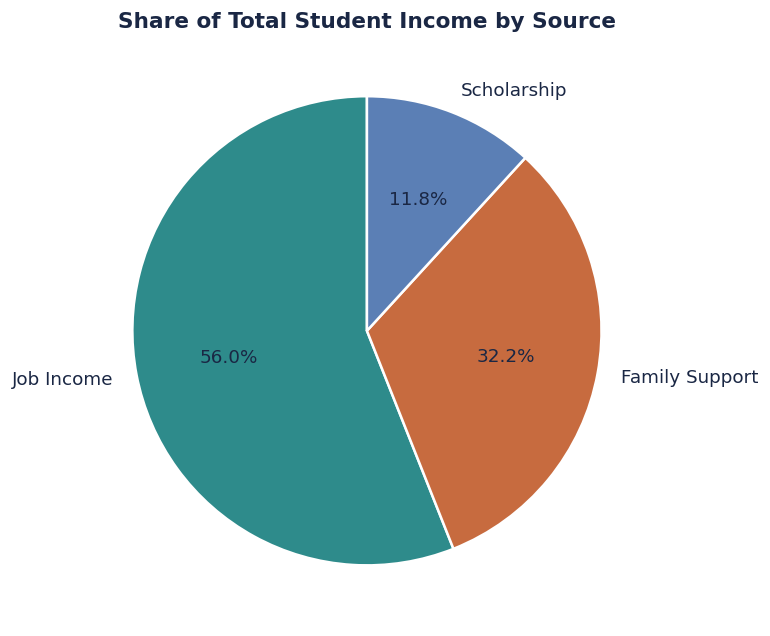

In [8]:
income_cols = ["monthly_job_income", "family_support_monthly", "scholarship_monthly_equiv"]
income_totals = df[income_cols].sum()
income_totals.index = ["Job Income", "Family Support", "Scholarship"]

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.pie(
    income_totals, labels=income_totals.index, autopct="%1.1f%%",
    colors=PALETTE, startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
    textprops={"color": NAVY, "fontsize": 11}
)
ax.set_title("Share of Total Student Income by Source")
plt.tight_layout()
plt.show()

<div style="background:#f4f6f9; border-left:5px solid #2e8b8b; padding:16px 20px; border-radius:6px; margin:6px 0 24px 0; font-family:'Segoe UI',Arial,sans-serif;">
<p style="margin:0 0 6px 0; font-weight:700; color:#2e8b8b; font-size:14px;">&#128161;&nbsp; Income mix</p>
<p style="margin:0; color:#2a2a2a; font-size:14.5px; line-height:1.55;">Across the full sample, <b>job income makes up the largest share</b> of total student income, with family support and scholarships filling meaningful but smaller roles &mdash; confirming that paid work, not just parental support, is the primary income engine for most students today.</p>
</div>

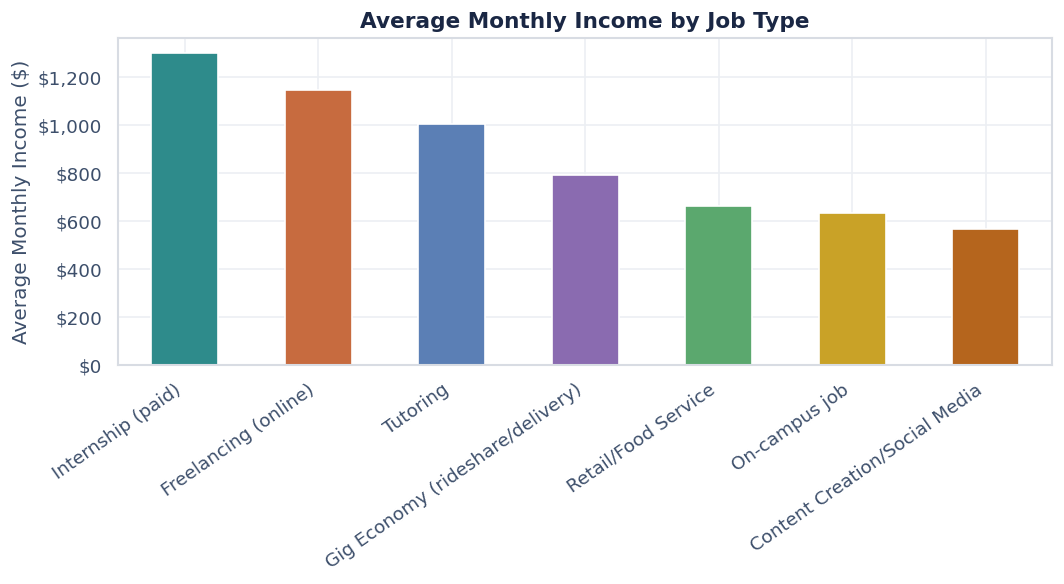

In [9]:
job_income_by_type = (
    df[df["has_job"]]
    .groupby("job_type")["monthly_job_income"]
    .mean()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 5))
job_income_by_type.plot(kind="bar", ax=ax, color=PALETTE, edgecolor="white")
ax.set_title("Average Monthly Income by Job Type")
ax.set_ylabel("Average Monthly Income ($)")
ax.set_xlabel("")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

<div style="background:#f4f6f9; border-left:5px solid #2e8b8b; padding:16px 20px; border-radius:6px; margin:6px 0 24px 0; font-family:'Segoe UI',Arial,sans-serif;">
<p style="margin:0 0 6px 0; font-weight:700; color:#2e8b8b; font-size:14px;">&#128161;&nbsp; Job type matters</p>
<p style="margin:0; color:#2a2a2a; font-size:14.5px; line-height:1.55;"><b>Paid internships and freelancing</b> pay noticeably better per student on average, while retail/food service and content creation &mdash; despite being some of the most common side hustles &mdash; trail behind. Choice of hustle appears to matter as much as hours worked.</p>
</div>

<div style="background: linear-gradient(135deg, #1a2744 0%, #3d4f6b 100%); padding: 28px 32px; border-radius: 10px; margin: 28px 0 18px 0; box-shadow: 0 2px 8px rgba(0,0,0,0.15);">
<table style="width:100%; border-collapse:collapse;"><tr>
<td style="width:56px; vertical-align:middle;">
<div style="background:#2e8b8b; color:white; width:44px; height:44px; border-radius:50%; display:flex; align-items:center; justify-content:center; font-size:20px; font-weight:700; font-family:Georgia,serif; text-align:center; line-height:44px;">05</div>
</td>
<td style="vertical-align:middle; padding-left:8px;">
<h2 style="color:white; margin:0; font-family:'Segoe UI',Arial,sans-serif; font-size:22px; font-weight:600; letter-spacing:0.3px;">Debt, Stress &amp; the &ldquo;Buy Now, Pay Later&rdquo; Trap</h2>
<p style="color:#b8c4d9; margin:4px 0 0 0; font-family:'Segoe UI',Arial,sans-serif; font-size:14px;">Student loans get the headlines, but BNPL usage is quietly just as common</p>
</td>
</tr></table>
</div>

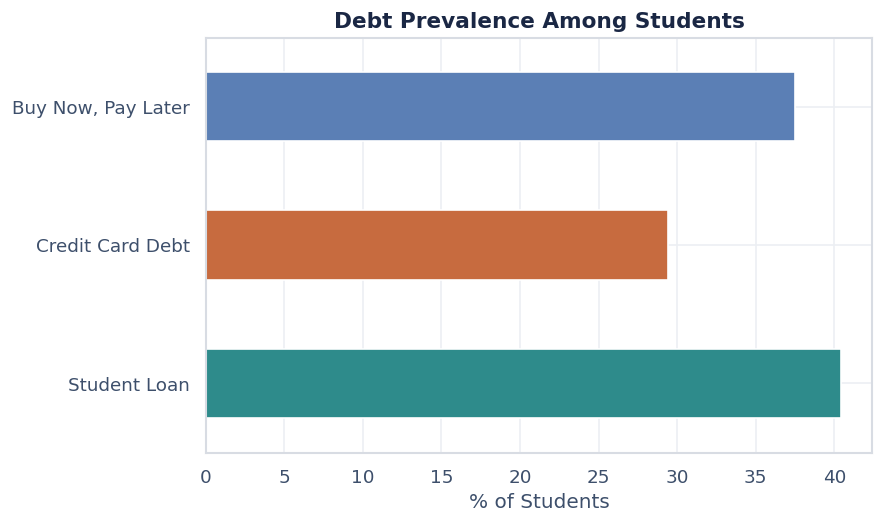

,% of students
Student Loan,40.4
Credit Card Debt,29.4
"Buy Now, Pay Later",37.5


In [10]:
debt_summary = pd.DataFrame({
    "% of students": [
        df["has_student_loan"].mean() * 100,
        df["has_credit_card_debt"].mean() * 100,
        df["uses_buy_now_pay_later"].mean() * 100,
    ]
}, index=["Student Loan", "Credit Card Debt", "Buy Now, Pay Later"]).round(1)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
debt_summary["% of students"].plot(kind="barh", ax=ax, color=[ACCENT, ACCENT2, "#5b7fb5"], edgecolor="white")
ax.set_title("Debt Prevalence Among Students")
ax.set_xlabel("% of Students")
plt.tight_layout()
plt.show()

debt_summary

<div style="background:#f4f6f9; border-left:5px solid #b5651d; padding:16px 20px; border-radius:6px; margin:6px 0 24px 0; font-family:'Segoe UI',Arial,sans-serif;">
<p style="margin:0 0 6px 0; font-weight:700; color:#b5651d; font-size:14px;">&#9888;&#65039;&nbsp; Debt prevalence</p>
<p style="margin:0; color:#2a2a2a; font-size:14.5px; line-height:1.55;">Student loans remain the most common debt type, but <b>BNPL usage rivals credit card debt</b> in prevalence &mdash; a distinctly modern spending pattern worth tracking alongside traditional debt metrics.</p>
</div>

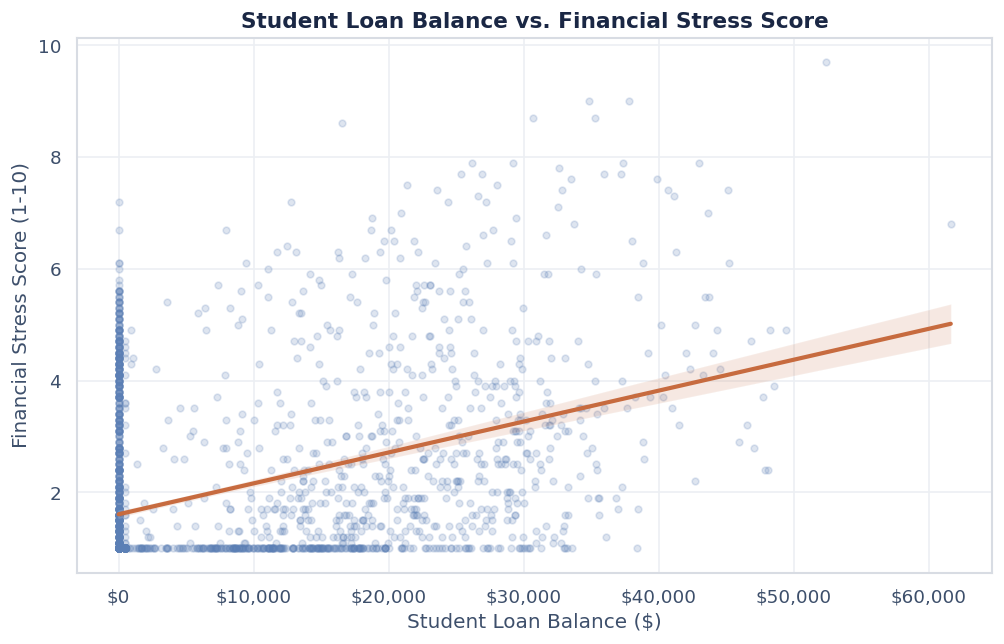

Pearson correlation: 0.408


In [11]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
sns.regplot(
    data=df, x="student_loan_balance", y="financial_stress_score",
    scatter_kws={"alpha": 0.2, "s": 16, "color": "#5b7fb5"},
    line_kws={"color": ACCENT2, "linewidth": 2.5}
)
ax.set_title("Student Loan Balance vs. Financial Stress Score")
ax.set_xlabel("Student Loan Balance ($)")
ax.set_ylabel("Financial Stress Score (1-10)")
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))
plt.tight_layout()
plt.show()

corr = df["student_loan_balance"].corr(df["financial_stress_score"])
print(f"Pearson correlation: {corr:.3f}")

<div style="background:#f4f6f9; border-left:5px solid #b5651d; padding:16px 20px; border-radius:6px; margin:6px 0 24px 0; font-family:'Segoe UI',Arial,sans-serif;">
<p style="margin:0 0 6px 0; font-weight:700; color:#b5651d; font-size:14px;">&#9888;&#65039;&nbsp; Debt drives stress</p>
<p style="margin:0; color:#2a2a2a; font-size:14.5px; line-height:1.55;">One of the strongest relationships in the dataset: <b>r &asymp; 0.41</b> between loan balance and stress score. Debt load is a meaningfully stronger predictor of financial stress than almost any other single variable examined here.</p>
</div>

<div style="background: linear-gradient(135deg, #1a2744 0%, #3d4f6b 100%); padding: 28px 32px; border-radius: 10px; margin: 28px 0 18px 0; box-shadow: 0 2px 8px rgba(0,0,0,0.15);">
<table style="width:100%; border-collapse:collapse;"><tr>
<td style="width:56px; vertical-align:middle;">
<div style="background:#2e8b8b; color:white; width:44px; height:44px; border-radius:50%; display:flex; align-items:center; justify-content:center; font-size:20px; font-weight:700; font-family:Georgia,serif; text-align:center; line-height:44px;">06</div>
</td>
<td style="vertical-align:middle; padding-left:8px;">
<h2 style="color:white; margin:0; font-family:'Segoe UI',Arial,sans-serif; font-size:22px; font-weight:600; letter-spacing:0.3px;">Does Financial Stress Drag Down GPA Too?</h2>
<p style="color:#b8c4d9; margin:4px 0 0 0; font-family:'Segoe UI',Arial,sans-serif; font-size:14px;">Connecting the wellbeing dimension back to academic outcomes</p>
</td>
</tr></table>
</div>

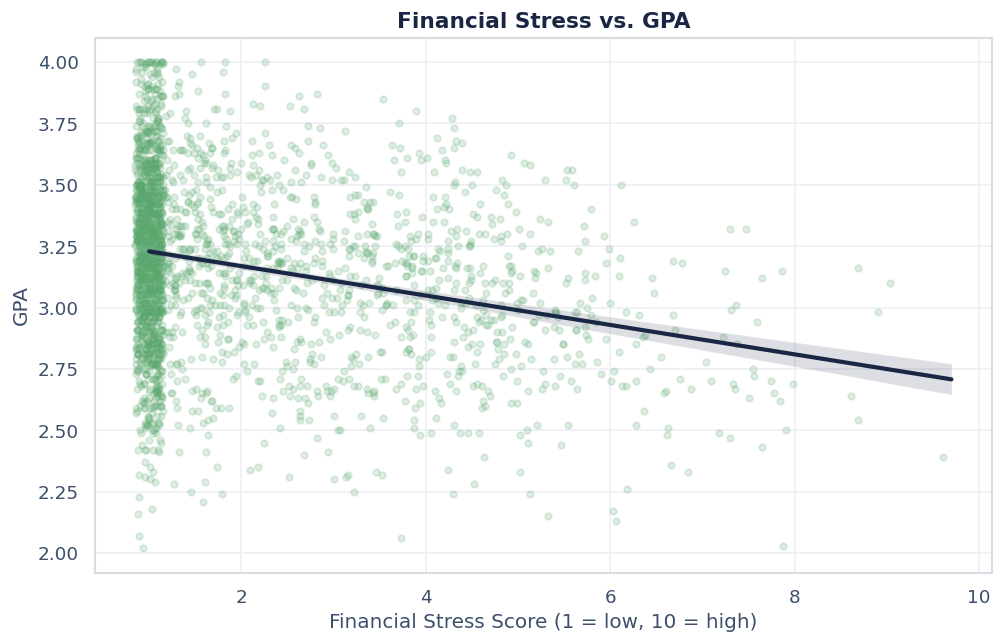

Pearson correlation: -0.261


In [12]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
sns.regplot(
    data=df, x="financial_stress_score", y="gpa",
    x_jitter=0.15,
    scatter_kws={"alpha": 0.2, "s": 16, "color": "#5ba86e"},
    line_kws={"color": NAVY, "linewidth": 2.5}
)
ax.set_title("Financial Stress vs. GPA")
ax.set_xlabel("Financial Stress Score (1 = low, 10 = high)")
ax.set_ylabel("GPA")
plt.tight_layout()
plt.show()

corr = df["financial_stress_score"].corr(df["gpa"])
print(f"Pearson correlation: {corr:.3f}")

<div style="background:#f4f6f9; border-left:5px solid #c76b3f; padding:16px 20px; border-radius:6px; margin:6px 0 24px 0; font-family:'Segoe UI',Arial,sans-serif;">
<p style="margin:0 0 6px 0; font-weight:700; color:#c76b3f; font-size:14px;">&#128202;&nbsp; Money worries bleed into academics</p>
<p style="margin:0; color:#2a2a2a; font-size:14.5px; line-height:1.55;">Financial stress correlates with lower GPA (r &asymp; -0.26) &mdash; on par with the work-hours effect. This suggests financial wellbeing programs on campus could have an academic payoff, not just a wellbeing one.</p>
</div>

<div style="background: linear-gradient(135deg, #1a2744 0%, #3d4f6b 100%); padding: 28px 32px; border-radius: 10px; margin: 28px 0 18px 0; box-shadow: 0 2px 8px rgba(0,0,0,0.15);">
<table style="width:100%; border-collapse:collapse;"><tr>
<td style="width:56px; vertical-align:middle;">
<div style="background:#2e8b8b; color:white; width:44px; height:44px; border-radius:50%; display:flex; align-items:center; justify-content:center; font-size:20px; font-weight:700; font-family:Georgia,serif; text-align:center; line-height:44px;">07</div>
</td>
<td style="vertical-align:middle; padding-left:8px;">
<h2 style="color:white; margin:0; font-family:'Segoe UI',Arial,sans-serif; font-size:22px; font-weight:600; letter-spacing:0.3px;">The AI-for-Schoolwork Trend</h2>
<p style="color:#b8c4d9; margin:4px 0 0 0; font-family:'Segoe UI',Arial,sans-serif; font-size:14px;">Who's using AI tools, how much, and does it show up in GPA?</p>
</td>
</tr></table>
</div>

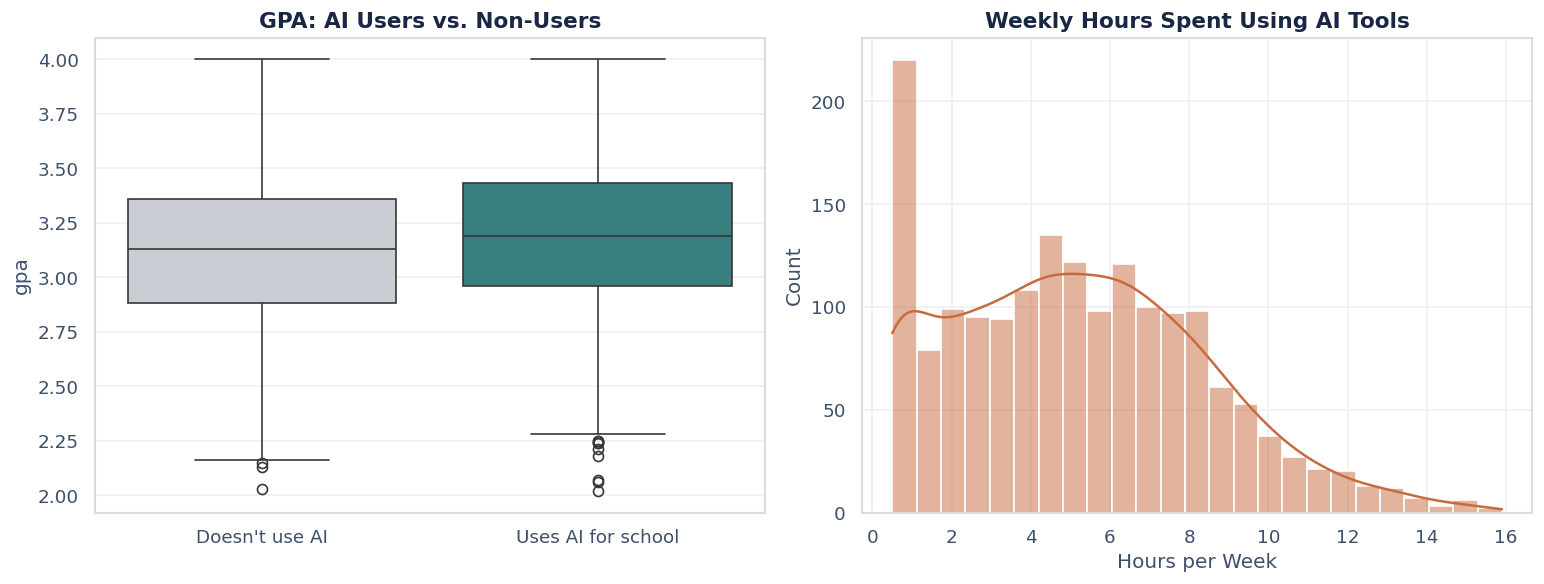

70.8% of students use AI tools for schoolwork
Of those, 41.6% pay for a premium AI subscription


In [13]:
ai_rate = df["uses_ai_tools_for_school"].mean() * 100
paid_rate = df.loc[df["uses_ai_tools_for_school"], "pays_for_ai_subscription"].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(
    data=df, x="uses_ai_tools_for_school", y="gpa", hue="uses_ai_tools_for_school", ax=axes[0],
    palette=["#c9ccd4", ACCENT], legend=False
)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Doesn't use AI", "Uses AI for school"])
axes[0].set_title("GPA: AI Users vs. Non-Users")
axes[0].set_xlabel("")

sns.histplot(
    df.loc[df["uses_ai_tools_for_school"], "ai_tool_weekly_hours"],
    bins=25, ax=axes[1], color=ACCENT2, kde=True
)
axes[1].set_title("Weekly Hours Spent Using AI Tools")
axes[1].set_xlabel("Hours per Week")

plt.tight_layout()
plt.show()

print(f"{ai_rate:.1f}% of students use AI tools for schoolwork")
print(f"Of those, {paid_rate:.1f}% pay for a premium AI subscription")

<div style="background:#f4f6f9; border-left:5px solid #2e8b8b; padding:16px 20px; border-radius:6px; margin:6px 0 24px 0; font-family:'Segoe UI',Arial,sans-serif;">
<p style="margin:0 0 6px 0; font-weight:700; color:#2e8b8b; font-size:14px;">&#128161;&nbsp; AI adoption is now mainstream</p>
<p style="margin:0; color:#2a2a2a; font-size:14.5px; line-height:1.55;">The majority of students already use AI tools for schoolwork, and a meaningful share pay for premium access &mdash; weekly usage clusters around a moderate few hours a week rather than constant use, suggesting supplemental rather than wholesale reliance.</p>
</div>

<div style="background: linear-gradient(135deg, #1a2744 0%, #3d4f6b 100%); padding: 28px 32px; border-radius: 10px; margin: 28px 0 18px 0; box-shadow: 0 2px 8px rgba(0,0,0,0.15);">
<table style="width:100%; border-collapse:collapse;"><tr>
<td style="width:56px; vertical-align:middle;">
<div style="background:#2e8b8b; color:white; width:44px; height:44px; border-radius:50%; display:flex; align-items:center; justify-content:center; font-size:20px; font-weight:700; font-family:Georgia,serif; text-align:center; line-height:44px;">08</div>
</td>
<td style="vertical-align:middle; padding-left:8px;">
<h2 style="color:white; margin:0; font-family:'Segoe UI',Arial,sans-serif; font-size:22px; font-weight:600; letter-spacing:0.3px;">Impulse Spending &amp; Lifestyle Creep</h2>
<p style="color:#b8c4d9; margin:4px 0 0 0; font-family:'Segoe UI',Arial,sans-serif; font-size:14px;">Does self-reported impulsivity actually show up in the wallet?</p>
</td>
</tr></table>
</div>

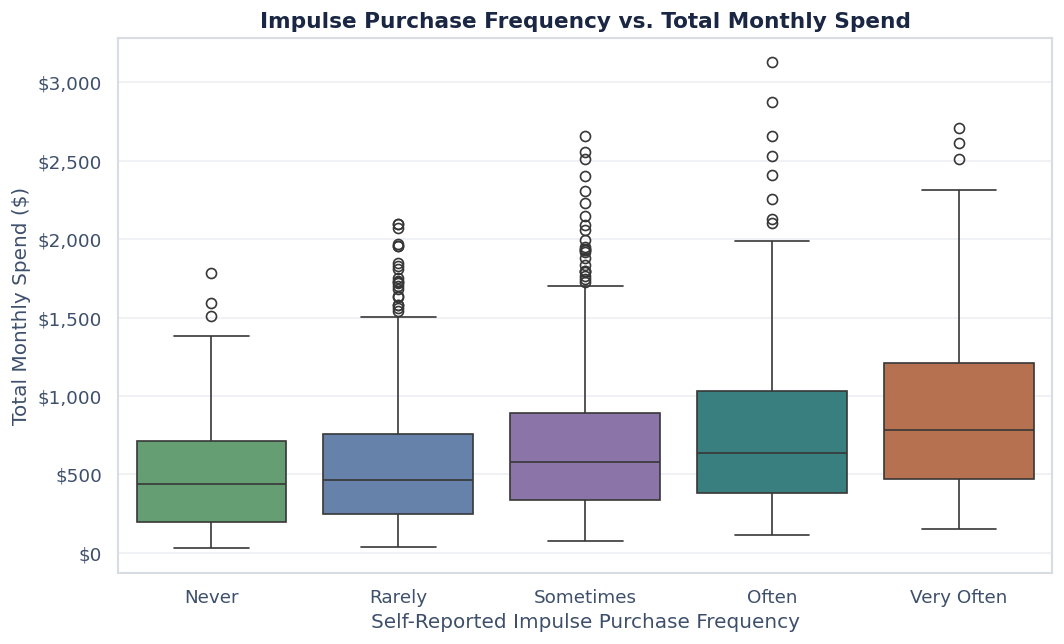

In [14]:
order = ["Never", "Rarely", "Sometimes", "Often", "Very Often"]
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.boxplot(
    data=df, x="impulse_purchase_frequency", y="total_monthly_spend",
    hue="impulse_purchase_frequency", order=order, palette=PALETTE[:5], legend=False, ax=ax
)
ax.set_title("Impulse Purchase Frequency vs. Total Monthly Spend")
ax.set_xlabel("Self-Reported Impulse Purchase Frequency")
ax.set_ylabel("Total Monthly Spend ($)")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))
plt.tight_layout()
plt.show()

<div style="background:#f4f6f9; border-left:5px solid #2e8b8b; padding:16px 20px; border-radius:6px; margin:6px 0 24px 0; font-family:'Segoe UI',Arial,sans-serif;">
<p style="margin:0 0 6px 0; font-weight:700; color:#2e8b8b; font-size:14px;">&#128161;&nbsp; Self-report checks out</p>
<p style="margin:0; color:#2a2a2a; font-size:14.5px; line-height:1.55;">Median monthly spend rises steadily across the impulse-purchase scale from &ldquo;Never&rdquo; to &ldquo;Very Often.&rdquo; Self-reported impulsivity isn't just a feeling &mdash; it maps cleanly onto actual spending behavior (r &asymp; 0.23 with total spend).</p>
</div>

<div style="background: linear-gradient(135deg, #1a2744 0%, #3d4f6b 100%); padding: 28px 32px; border-radius: 10px; margin: 28px 0 18px 0; box-shadow: 0 2px 8px rgba(0,0,0,0.15);">
<table style="width:100%; border-collapse:collapse;"><tr>
<td style="width:56px; vertical-align:middle;">
<div style="background:#2e8b8b; color:white; width:44px; height:44px; border-radius:50%; display:flex; align-items:center; justify-content:center; font-size:20px; font-weight:700; font-family:Georgia,serif; text-align:center; line-height:44px;">09</div>
</td>
<td style="vertical-align:middle; padding-left:8px;">
<h2 style="color:white; margin:0; font-family:'Segoe UI',Arial,sans-serif; font-size:22px; font-weight:600; letter-spacing:0.3px;">Income vs. Savings</h2>
<p style="color:#b8c4d9; margin:4px 0 0 0; font-family:'Segoe UI',Arial,sans-serif; font-size:14px;">The strongest relationship in the dataset</p>
</td>
</tr></table>
</div>

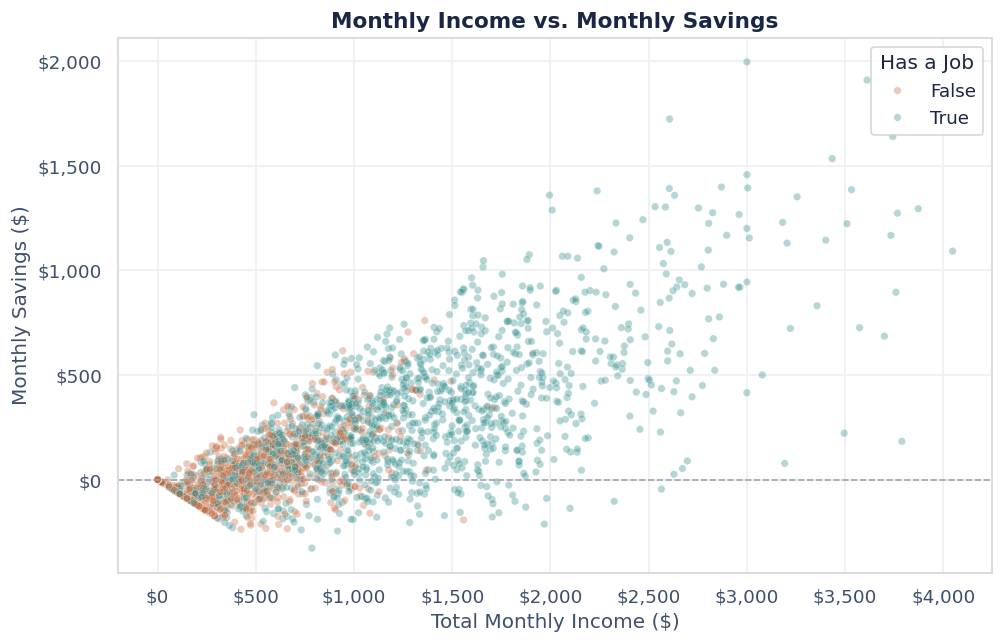

Pearson correlation: 0.760


In [15]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
sns.scatterplot(
    data=df, x="total_monthly_income", y="monthly_savings",
    hue="has_job", alpha=0.35, s=20, palette=[ACCENT2, ACCENT]
)
ax.axhline(0, color="#9aa4b2", linestyle="--", linewidth=1)
ax.set_title("Monthly Income vs. Monthly Savings")
ax.set_xlabel("Total Monthly Income ($)")
ax.set_ylabel("Monthly Savings ($)")
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))
ax.legend(title="Has a Job")
plt.tight_layout()
plt.show()

corr = df["total_monthly_income"].corr(df["monthly_savings"])
print(f"Pearson correlation: {corr:.3f}")

<div style="background:#f4f6f9; border-left:5px solid #2e7d5b; padding:16px 20px; border-radius:6px; margin:6px 0 24px 0; font-family:'Segoe UI',Arial,sans-serif;">
<p style="margin:0 0 6px 0; font-weight:700; color:#2e7d5b; font-size:14px;">&#9989;&nbsp; Income is the strongest single predictor</p>
<p style="margin:0; color:#2a2a2a; font-size:14.5px; line-height:1.55;">At r &asymp; 0.76, income vs. savings is by far the strongest relationship in the dataset. Higher income does get spent too (lifestyle creep), but a solid portion consistently converts into savings &mdash; more income reliably beats better budgeting habits alone.</p>
</div>

<div style="background: linear-gradient(135deg, #1a2744 0%, #3d4f6b 100%); padding: 28px 32px; border-radius: 10px; margin: 28px 0 18px 0; box-shadow: 0 2px 8px rgba(0,0,0,0.15);">
<table style="width:100%; border-collapse:collapse;"><tr>
<td style="width:56px; vertical-align:middle;">
<div style="background:#2e8b8b; color:white; width:44px; height:44px; border-radius:50%; display:flex; align-items:center; justify-content:center; font-size:20px; font-weight:700; font-family:Georgia,serif; text-align:center; line-height:44px;">10</div>
</td>
<td style="vertical-align:middle; padding-left:8px;">
<h2 style="color:white; margin:0; font-family:'Segoe UI',Arial,sans-serif; font-size:22px; font-weight:600; letter-spacing:0.3px;">Correlation Heatmap &amp; Key Takeaways</h2>
<p style="color:#b8c4d9; margin:4px 0 0 0; font-family:'Segoe UI',Arial,sans-serif; font-size:14px;">The full picture, side by side</p>
</td>
</tr></table>
</div>

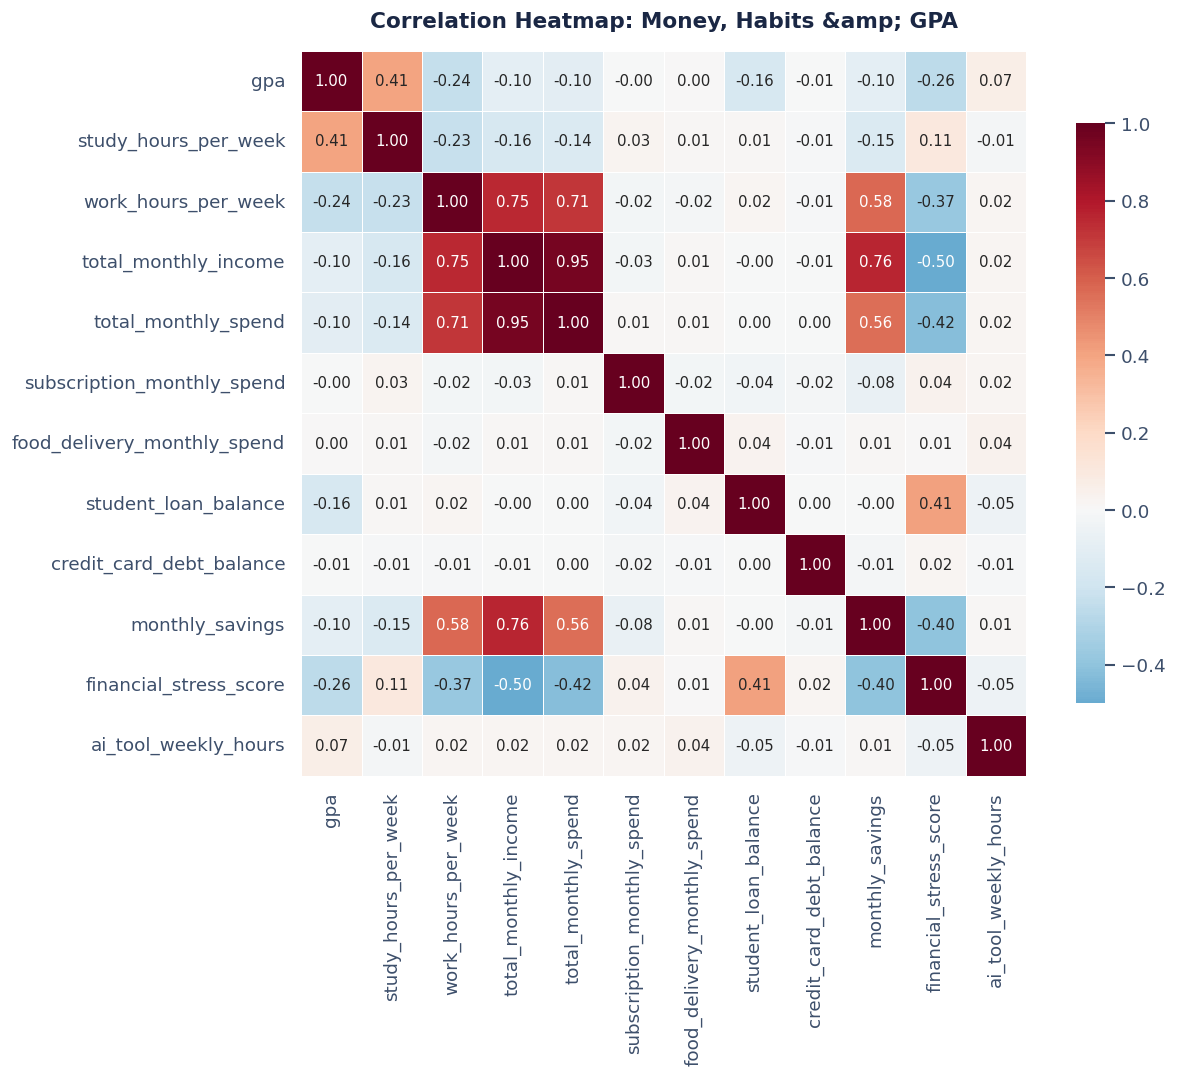

In [16]:
numeric_cols = [
    "gpa", "study_hours_per_week", "work_hours_per_week", "total_monthly_income",
    "total_monthly_spend", "subscription_monthly_spend", "food_delivery_monthly_spend",
    "student_loan_balance", "credit_card_debt_balance", "monthly_savings",
    "financial_stress_score", "ai_tool_weekly_hours"
]

corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
    square=True, linewidths=0.6, linecolor="white", ax=ax,
    cbar_kws={"shrink": 0.8}, annot_kws={"fontsize": 9}
)
ax.set_title("Correlation Heatmap: Money, Habits &amp; GPA", pad=14)
plt.tight_layout()
plt.show()

<div style="background:#f4f6f9; border-left:5px solid #2e8b8b; padding:16px 20px; border-radius:6px; margin:6px 0 24px 0; font-family:'Segoe UI',Arial,sans-serif;">
<p style="margin:0 0 6px 0; font-weight:700; color:#2e8b8b; font-size:14px;">&#128161;&nbsp; Reading the heatmap</p>
<p style="margin:0; color:#2a2a2a; font-size:14.5px; line-height:1.55;">The strongest blocks are: <b>income &harr; savings</b> (strongly positive), <b>debt &harr; financial stress</b> (moderately positive), and <b>stress &amp; work hours &harr; GPA</b> (both mildly negative). No single lifestyle factor dominates GPA outcomes &mdash; it's the accumulation of financial pressure that matters most.</p>
</div>

<div style="background:linear-gradient(135deg, #1a2744 0%, #3d4f6b 100%); padding:32px 34px; border-radius:12px; margin-top:10px; font-family:'Segoe UI',Arial,sans-serif;">
<h2 style="color:white; margin:0 0 18px 0; font-size:21px;">&#128209; Key Takeaways</h2>
<table style="border-collapse:collapse; width:100%;">
<tr><td style="padding:8px 0; vertical-align:top; width:28px; color:#2e8b8b; font-size:16px;">&#9679;</td><td style="padding:8px 0; color:#dbe3f0; font-size:14.5px; line-height:1.6;"><b style="color:white;">Work hours and GPA trade off</b> &mdash; grades start slipping once weekly work climbs past roughly 12&ndash;15 hours.</td></tr>
<tr><td style="padding:8px 0; vertical-align:top; color:#2e8b8b;font-size:16px;">&#9679;</td><td style="padding:8px 0; color:#dbe3f0; font-size:14.5px; line-height:1.6;"><b style="color:white;">Financial stress correlates with lower GPA</b>, not just lower bank balances &mdash; money worries bleed into academics.</td></tr>
<tr><td style="padding:8px 0; vertical-align:top; color:#2e8b8b;font-size:16px;">&#9679;</td><td style="padding:8px 0; color:#dbe3f0; font-size:14.5px; line-height:1.6;"><b style="color:white;">Debt drives stress</b> &mdash; student loan balance is one of the strongest positive correlates of financial stress score.</td></tr>
<tr><td style="padding:8px 0; vertical-align:top; color:#2e8b8b;font-size:16px;">&#9679;</td><td style="padding:8px 0; color:#dbe3f0; font-size:14.5px; line-height:1.6;"><b style="color:white;">Income strongly predicts savings</b> &mdash; but spending scales with income too (lifestyle creep).</td></tr>
<tr><td style="padding:8px 0; vertical-align:top; color:#2e8b8b;font-size:16px;">&#9679;</td><td style="padding:8px 0; color:#dbe3f0; font-size:14.5px; line-height:1.6;"><b style="color:white;">AI tool usage for schoolwork is now the norm</b>, not the exception, among this student population.</td></tr>
<tr><td style="padding:8px 0; vertical-align:top; color:#2e8b8b;font-size:16px;">&#9679;</td><td style="padding:8px 0; color:#dbe3f0; font-size:14.5px; line-height:1.6;"><b style="color:white;">Impulse buying tendency maps cleanly onto total spend</b> &mdash; self-reported impulsivity isn't just a feeling, it shows up in the wallet.</td></tr>
</table>
</div>

<div style="background:#f4f6f9; border-radius:12px; padding:26px 30px; margin-top:16px; font-family:'Segoe UI',Arial,sans-serif;">
<h3 style="color:#1a2744; margin:0 0 12px 0; font-size:17px;">&#128640; Ideas to Take This Further</h3>
<ul style="color:#3d4f6b; font-size:14.5px; line-height:1.8; margin:0; padding-left:22px;">
<li>Build a GPA predictor using income/work/stress features</li>
<li>Cluster students into &ldquo;financial personas&rdquo; (e.g. hustler, saver, stressed spender)</li>
<li>Explore regional differences in income mix and debt reliance</li>
<li>Test whether budgeting app usage actually reduces financial stress</li>
</ul>
</div>

<div style="text-align:center; margin-top:26px; padding:18px; font-family:'Segoe UI',Arial,sans-serif;">
<p style="color:#3d4f6b; font-size:14px;">If you found this notebook useful, an upvote helps a lot &#128591; &mdash; and feel free to fork and extend the analysis!</p>
</div>